In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [19]:
#s = tau/k_1

simulation_config = {
    'N_omegas': 2 ** 8, #число рассматриваемых частот/значений tau
    'N_scans': 10000, #число сканов формы импульса
    'scan width/initial temporal width': 7, #ширина скана
    'fiber_length, m': 2e3, #длина волокна в м
    'k_1, s/m': 5e-9,
    'k_2, s^2/m^2': -2e-14,
    'gamma': 1e-2,
    'initial_duration, s': 4e-14, #начальная характерная ширина импульса в с
    'initial max amplitude': 0.001 #начальная максимальная амплитуда
}

100%|████████████████████████████████████| 9999/9999 [00:00<00:00, 35293.15it/s]


0.1767766952966369


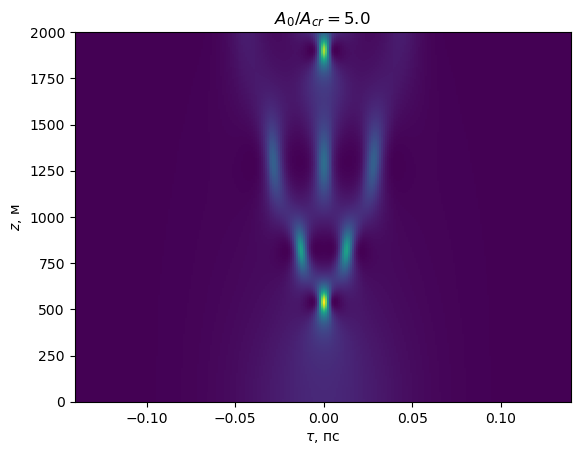

In [37]:
class SIM_config:
    def __init__(self, config):
        self.N_omegas = config['N_omegas']
        self.N_scans = config['N_scans']
        self.width = config['scan width/initial temporal width']
        self.length = config['fiber_length, m']
        self.k_1 = config['k_1, s/m']
        self.k_2 = config['k_2, s^2/m^2']
        self.gamma = config['gamma']
        self.duration = config['initial_duration, s']
        
        self.dz = self.length / self.N_scans
        self.A = config['initial max amplitude']
        self.B = self.k_1 / self.duration #форма начального импульса A/cosh(Bs)
        self.A_critical = np.sqrt(-self.k_2 * self.B ** 2 / self.gamma) #стационарное решение
        self.A = 5.0 * self.A_critical
        self.s_step = self.width * self.duration / self.k_1 / self.N_omegas #разрешение скана
        
        self.s_array = np.linspace(-self.N_omegas // 2, self.N_omegas // 2 - 1, self.N_omegas) * self.s_step
        self.dispersion = (2 * np.pi * self.s_array / self.N_omegas / (self.s_step ** 2)) #используется во время применения линейного оператора
        
    def SSFM(self):
        sim = self
        #определение начальной формы импульса
        E_time_domain_initial = sim.A / (np.cosh(sim.B * (sim.s_array)))

        #создание массива решений
        sol = np.ndarray(shape=(sim.N_scans, sim.N_omegas), dtype=complex)
        sol[0] = E_time_domain_initial

        for i in tqdm(range(1, sim.N_scans)):
            row = sol[i-1]
            #нелинейного оператора пока нет
            
            row = np.exp(sim.dz * 1j * sim.gamma * np.abs(row) ** 2) * row
            
            #линейный оператор
            row = np.fft.fft(row)
            row = np.fft.ifftshift(row)
            row = np.exp(sim.dz * 1j * sim.k_2 / 2 * (sim.dispersion ** 2)) * row

            #возращаем во временное представление
            row = np.fft.fftshift(row) / sim.N_omegas
            row = np.fft.fft(row)
            sol[i] = row

        self.solution = sol
        return sol
    
    def visualise(self):
        sim = self
        Ls = np.linspace(0, sim.length, sim.N_scans)
        plt.pcolormesh(sim.s_array * self.k_1 * 1e12, Ls, np.abs(sim.solution) ** 2)
        plt.xlabel('$\\tau$, пс')
        plt.ylabel('$z$, м')
        plt.title('$A_0/A_{cr} = $' + str(round(self.A/self.A_critical, 1)))
    
SIM = SIM_config(simulation_config)
SIM.SSFM()
SIM.visualise()
print(SIM.A_critical)
plt.savefig('strong focus.png')